# 03 - Supervised Modeling

## Modelos supervisados para clasificación y regresión del riesgo operacional

En este notebook se implementan los modelos supervisados principales del proyecto.

Después de seleccionar los targets finales en el notebook `02_target_selection_and_problem_definition.ipynb`, se continúa con el entrenamiento y comparación de modelos para dos problemas:

1. **Clasificación:** predecir si un envío tendrá alto riesgo operacional.
2. **Regresión:** estimar el nivel numérico de riesgo operacional.

Este notebook responde a la pregunta:

> ¿Qué modelos supervisados funcionan mejor antes de optimizar hiperparámetros?


# Objetivo del notebook

En esta etapa busco:

- cargar el dataset final `dataset_modelo_v3.csv`;
- definir los dos problemas supervisados finales;
- preparar variables predictoras;
- construir pipelines de preprocesamiento;
- entrenar múltiples modelos de clasificación;
- entrenar múltiples modelos de regresión;
- comparar métricas de rendimiento;
- interpretar los resultados desde una perspectiva técnica y operacional.

Importante: en este notebook todavía no se realiza optimización de hiperparámetros.  
La optimización se realizará en el notebook `04_hyperparameter_optimization.ipynb`.


# 1. Contexto del modelado supervisado

El modelado supervisado requiere una variable objetivo conocida.

En este proyecto se seleccionaron dos targets finales:

## Clasificación

`riesgo_operacional_alto`

Permite responder:

> ¿Este envío pertenece al grupo de alto riesgo operacional?

## Regresión

`riesgo_operacional`

Permite responder:

> ¿Cuál es el nivel estimado de riesgo operacional del envío?

Ambos enfoques se complementan: la regresión estima la intensidad del riesgo y la clasificación transforma ese riesgo en una alerta operativa.


# 2. Importación de librerías

Se importan las librerías necesarias para manipulación de datos, visualización, preprocesamiento, modelado y evaluación.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Modelos de regresión
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Métricas de clasificación
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# Métricas de regresión
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)


# 3. Carga del dataset

Se carga el dataset final generado en la etapa de limpieza y feature engineering.


In [2]:
df = pd.read_csv("data/05_model_input/dataset_modelo_v3.csv")

print("Dimensiones del dataset:", df.shape)

df.head()


Dimensiones del dataset: (998, 56)


,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,destino,distancia_km,tiempo_estimado_hrs,tipo_via,peaje_total,placa,tipo,capacidad_kg,capacidad_m3,año_fabricacion,estado_vehiculo,km_recorridos,cantidad_incidencias,costo_total_incidencias,tipo_incidencia_principal,tiene_incidencia,dias_entrega,velocidad_promedio_km_h,uso_capacidad_kg,uso_capacidad_m3,entrega_tardia,peso_kg_original,distancia_km_original,velocidad_promedio_km_h_original,uso_capacidad_kg_original,uso_capacidad_m3_original,uso_capacidad_kg_recalculado,uso_capacidad_m3_recalculado,antiguedad_vehiculo,densidad_carga,riesgo_operacional,riesgo_velocidad,vehiculo_exigido,sobrecarga_kg,ruta_larga,velocidad_alta,vehiculo_riesgoso_estado,via_compleja,peso_kg_log,distancia_km_log,volumen_m3_log,velocidad_promedio_km_h_log,densidad_carga_log,riesgo_operacional_log,riesgo_velocidad_log,km_recorridos_log
0,1.0,2023-01-01,39.0,46.0,12675.8,28.48,peligrosa,entregado,2023-01-05,valparaíso,chillán,919.3,16.7,urbana,1950.0,ouuc-52,camión,10000.0,20.5,2022.0,en mantención,17043.0,0.0,0.0,sin incidencia,0.0,4.0,55.047904,1.26758,1.389268,1,12675.8,919.3,55.047904,1.26758,1.389268,1.26758,1.389268,4.0,445.061620,1165.286294,50605.538323,1,1,0,0,1,0,9.447529,6.824700,3.383712,4.026207,6.100457,7.061580,10.831836,9.743554
1,2.0,NaN,3.0,27.0,13.6,24.93,peligrosa,entregado,2023-01-05,rancagua,rengo,679.6,18.4,urbana,2447.0,fgkf-38,van,1000.0,22.1,2010.0,operativo,88004.0,0.0,0.0,sin incidencia,0.0,7.0,36.934783,0.01360,1.128054,1,13.6,679.6,36.934783,0.01360,1.128054,0.01360,1.128054,16.0,0.545506,9.242560,25100.878261,0,0,0,0,0,0,2.681022,6.522975,3.255401,3.635868,0.435351,2.326552,10.130698,11.385149
2,3.0,2023-01-02,73.0,18.0,2536.0,50.55,refrigerada,entregado,NaN,maipú,san antonio,468.4,5.2,ruta nacional,11768.0,agdn-22,furgón,20000.0,38.9,2023.0,en mantención,243705.0,0.0,0.0,sin incidencia,0.0,7.0,90.076923,0.12680,1.299486,1,2536.0,468.4,90.076923,0.12680,1.299486,0.12680,1.299486,3.0,50.167158,59.393120,42192.030769,0,0,0,0,1,1,7.838738,6.151455,3.942552,4.511704,3.935098,4.100875,10.650010,12.403718
3,4.0,2023-01-03,49.0,45.0,466.0,13.88,peligrosa,en tránsito,2023-01-07,las condes,osorno,1642.4,18.9,ruta nacional,7202.0,ialh-88,van,1000.0,25.3,2015.0,operativo,224573.5,1.0,1747372.0,desvío de ruta,1.0,4.0,86.899471,0.46600,0.548617,1,466.0,1642.4,86.899471,0.46600,0.548617,0.46600,0.548617,11.0,33.571068,765.358400,142723.691005,0,0,1,0,0,1,6.146329,7.404523,2.700018,4.476194,3.543017,6.641650,11.868673,12.321963
4,5.0,NaN,17.0,36.0,4928.9,0.44,refrigerada,retrasado,2023-01-07,maipú,rancagua,1556.6,17.9,urbana,3799.0,glfy-29,camioneta,5000.0,49.1,2023.0,operativo,138259.0,0.0,0.0,sin incidencia,0.0,7.0,86.960894,0.98578,0.008961,1,4928.9,1556.6,86.960894,0.98578,0.008961,0.98578,0.008961,3.0,11176.643991,1534.465148,135363.327374,1,0,1,0,0,0,8.503074,7.350901,0.364643,4.476892,9.321671,7.336589,11.815725,11.836891


## Análisis inicial

El dataset contiene la versión preparada para modelado.

Incluye variables originales tratadas, variables derivadas, transformaciones logarítmicas y métricas operacionales construidas para representar mejor el riesgo logístico.


# 4. Definición de targets finales

Se reconstruyen los targets finales para asegurar que el notebook sea reproducible.


In [3]:
# Target de clasificación: alto riesgo operacional.
percentil_riesgo = df["riesgo_operacional"].quantile(0.75)

df["riesgo_operacional_alto"] = np.where(
    df["riesgo_operacional"] >= percentil_riesgo,
    1,
    0
)

# Target de regresión.
target_regresion = "riesgo_operacional"

print("Umbral de alto riesgo operacional:", percentil_riesgo)

print("\nDistribución del target de clasificación:")
print(df["riesgo_operacional_alto"].value_counts())
print(df["riesgo_operacional_alto"].value_counts(normalize=True) * 100)


Umbral de alto riesgo operacional: 2279.9541040000004

Distribución del target de clasificación:
riesgo_operacional_alto
0    755
1    243
Name: count, dtype: int64
riesgo_operacional_alto
0    75.651303
1    24.348697
Name: proportion, dtype: float64


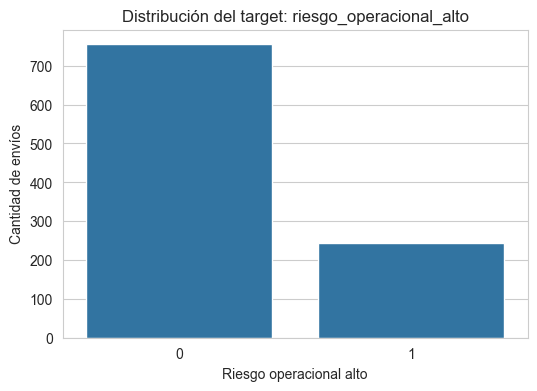

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="riesgo_operacional_alto")

plt.title("Distribución del target: riesgo_operacional_alto")
plt.xlabel("Riesgo operacional alto")
plt.ylabel("Cantidad de envíos")

plt.show()


## Análisis del target de clasificación

La variable `riesgo_operacional_alto` divide los envíos en dos grupos:

- 0: riesgo operacional normal o bajo;
- 1: riesgo operacional alto.

El umbral se definió usando el percentil 75 del riesgo operacional, por lo que aproximadamente el 25% de los envíos queda clasificado como alto riesgo.

Esta distribución es más adecuada que otros targets evaluados anteriormente, porque tiene una clase positiva suficientemente representada y permite construir un problema de clasificación útil para la operación.


# 5. Selección de variables predictoras

Se utilizan variables operacionales, variables derivadas y transformaciones logarítmicas.

No se utiliza `riesgo_operacional` como predictor para clasificación, ya que es la base del target `riesgo_operacional_alto`.

Para la regresión tampoco se usa `riesgo_operacional` dentro de X, porque es la variable que se quiere predecir.


In [5]:
variables_base = [
    "distancia_km",
    "tiempo_estimado_hrs",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "velocidad_promedio_km_h",
    "km_recorridos",
    "tipo_via",
    "tipo_carga",
    "estado_vehiculo",
    "tipo",
    "uso_capacidad_kg",
    "uso_capacidad_m3",
    "uso_capacidad_kg_recalculado",
    "uso_capacidad_m3_recalculado",
    "antiguedad_vehiculo",
    "densidad_carga",
    "riesgo_velocidad",
    "vehiculo_exigido",
    "sobrecarga_kg",
    "ruta_larga",
    "velocidad_alta",
    "vehiculo_riesgoso_estado",
    "via_compleja",
    "peso_kg_log",
    "distancia_km_log",
    "volumen_m3_log",
    "velocidad_promedio_km_h_log",
    "densidad_carga_log",
    "riesgo_velocidad_log",
    "km_recorridos_log"
]

variables_modelo = [col for col in variables_base if col in df.columns]

print("Cantidad de variables predictoras:", len(variables_modelo))
variables_modelo


Cantidad de variables predictoras: 32



[
    'distancia_km',
    'tiempo_estimado_hrs',
    'peso_kg',
    'volumen_m3',
    'capacidad_kg',
    'capacidad_m3',
    'velocidad_promedio_km_h',
    'km_recorridos',
    'tipo_via',
    'tipo_carga',
    'estado_vehiculo',
    'tipo',
    'uso_capacidad_kg',
    'uso_capacidad_m3',
    'uso_capacidad_kg_recalculado',
    'uso_capacidad_m3_recalculado',
    'antiguedad_vehiculo',
    'densidad_carga',
    'riesgo_velocidad',
    'vehiculo_exigido',
    'sobrecarga_kg',
    'ruta_larga',
    'velocidad_alta',
    'vehiculo_riesgoso_estado',
    'via_compleja',
    'peso_kg_log',
    'distancia_km_log',
    'volumen_m3_log',
    'velocidad_promedio_km_h_log',
    'densidad_carga_log',
    'riesgo_velocidad_log',
    'km_recorridos_log'
]

## Análisis de variables

Las variables seleccionadas representan dimensiones importantes de la operación:

- carga transportada;
- distancia y tiempo estimado;
- uso de capacidad;
- estado y tipo de vehículo;
- tipo de vía;
- sobrecarga;
- velocidad;
- variables logarítmicas para reducir asimetría.

Estas variables fueron seleccionadas porque están disponibles antes o durante la planificación del envío y no corresponden a resultados posteriores como incidencias ya ocurridas.


# 6. Construcción del preprocesador

Se crea un preprocesador común para todos los modelos.

El flujo incluye:

- imputación de valores nulos numéricos con mediana;
- escalamiento de variables numéricas;
- imputación de variables categóricas con la moda;
- codificación One Hot para variables categóricas.

Esto permite usar modelos que requieren datos numéricos y escalados, como KNN, SVM y regresiones.


In [6]:
def crear_preprocesador(X):
    variables_numericas = X.select_dtypes(include=np.number).columns.tolist()
    variables_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

    transformador_numerico = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    transformador_categorico = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocesador = ColumnTransformer([
        ("num", transformador_numerico, variables_numericas),
        ("cat", transformador_categorico, variables_categoricas)
    ])

    return preprocesador


# 7. Modelado de clasificación

## Target: `riesgo_operacional_alto`

En esta sección se entrenan los modelos de clasificación solicitados:

- Logistic Regression;
- Decision Tree;
- Random Forest;
- KNN;
- SVM;
- Gaussian Naive Bayes.

La métrica principal será el **F1-score**, considerando también precision, recall y balanced accuracy.


In [7]:
X_clf = df[variables_modelo].copy()
y_clf = df["riesgo_operacional_alto"].copy()

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print("X_train:", X_train_clf.shape)
print("X_test:", X_test_clf.shape)

print("\nDistribución y_train:")
print(y_train_clf.value_counts(normalize=True) * 100)

print("\nDistribución y_test:")
print(y_test_clf.value_counts(normalize=True) * 100)


X_train: (798, 32)
X_test: (200, 32)

Distribución y_train:
riesgo_operacional_alto
0    75.689223
1    24.310777
Name: proportion, dtype: float64

Distribución y_test:
riesgo_operacional_alto
0    75.5
1    24.5
Name: proportion, dtype: float64


## Análisis de la división train/test

Se usa `stratify=y` para mantener proporciones similares de riesgo alto y riesgo normal en entrenamiento y prueba.

Esto es importante porque el target tiene cierto desbalance: la clase de alto riesgo representa cerca del 25% de los datos.


# 8. Función de evaluación para clasificación

Se define una función para entrenar y evaluar todos los modelos de clasificación bajo el mismo criterio.


In [8]:
def evaluar_modelo_clasificacion(nombre_modelo, modelo, X_train, X_test, y_train, y_test):
    pipeline = Pipeline([
        ("preprocesamiento", crear_preprocesador(X_train)),
        ("modelo", modelo)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    resultado = {
        "modelo": nombre_modelo,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0)
    }

    print(f"===== {nombre_modelo} =====")
    print(f"Accuracy          : {resultado['accuracy']:.4f}")
    print(f"Balanced Accuracy : {resultado['balanced_accuracy']:.4f}")
    print(f"Precision         : {resultado['precision']:.4f}")
    print(f"Recall            : {resultado['recall']:.4f}")
    print(f"F1-score          : {resultado['f1_score']:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    matriz = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
    disp.plot()
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.show()

    return resultado, pipeline


# 9. Entrenamiento de modelos de clasificación

Se entrenan los modelos base sin optimización exhaustiva de hiperparámetros.


===== Logistic Regression =====
Accuracy          : 0.9450
Balanced Accuracy : 0.9567
Precision         : 0.8276
Recall            : 0.9796
F1-score          : 0.8972

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96       151
           1       0.83      0.98      0.90        49

    accuracy                           0.94       200
   macro avg       0.91      0.96      0.93       200
weighted avg       0.95      0.94      0.95       200



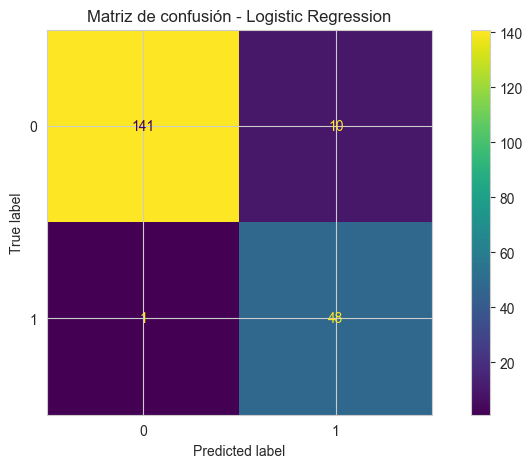

===== Decision Tree =====
Accuracy          : 0.9650
Balanced Accuracy : 0.9630
Precision         : 0.9038
Recall            : 0.9592
F1-score          : 0.9307

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       151
           1       0.90      0.96      0.93        49

    accuracy                           0.96       200
   macro avg       0.95      0.96      0.95       200
weighted avg       0.97      0.96      0.97       200



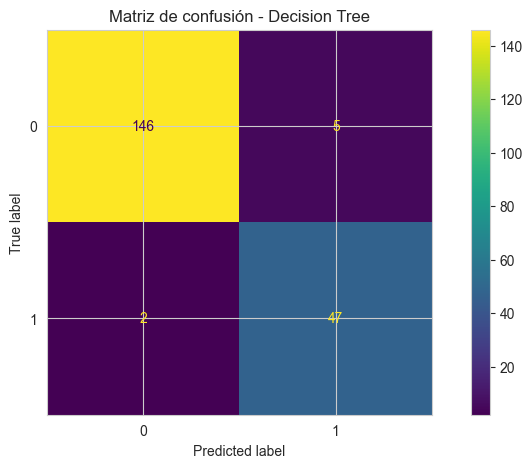

===== Random Forest =====
Accuracy          : 0.9800
Balanced Accuracy : 0.9799
Precision         : 0.9412
Recall            : 0.9796
F1-score          : 0.9600

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       151
           1       0.94      0.98      0.96        49

    accuracy                           0.98       200
   macro avg       0.97      0.98      0.97       200
weighted avg       0.98      0.98      0.98       200



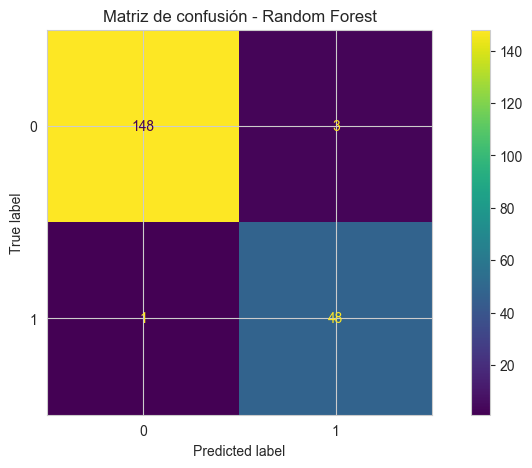

===== KNN =====
Accuracy          : 0.9250
Balanced Accuracy : 0.9090
Precision         : 0.8269
Recall            : 0.8776
F1-score          : 0.8515

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       151
           1       0.83      0.88      0.85        49

    accuracy                           0.93       200
   macro avg       0.89      0.91      0.90       200
weighted avg       0.93      0.93      0.93       200



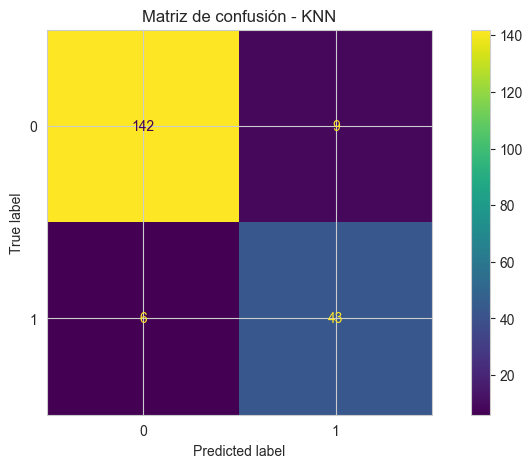

===== SVM =====
Accuracy          : 0.9350
Balanced Accuracy : 0.9432
Precision         : 0.8103
Recall            : 0.9592
F1-score          : 0.8785

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96       151
           1       0.81      0.96      0.88        49

    accuracy                           0.94       200
   macro avg       0.90      0.94      0.92       200
weighted avg       0.94      0.94      0.94       200



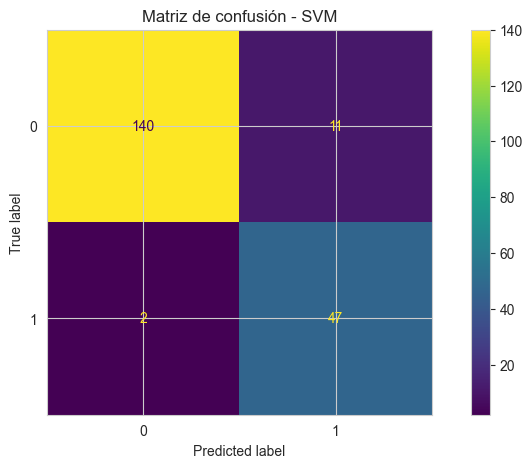

===== Gaussian NB =====
Accuracy          : 0.9000
Balanced Accuracy : 0.9269
Precision         : 0.7164
Recall            : 0.9796
F1-score          : 0.8276

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.87      0.93       151
           1       0.72      0.98      0.83        49

    accuracy                           0.90       200
   macro avg       0.85      0.93      0.88       200
weighted avg       0.92      0.90      0.90       200



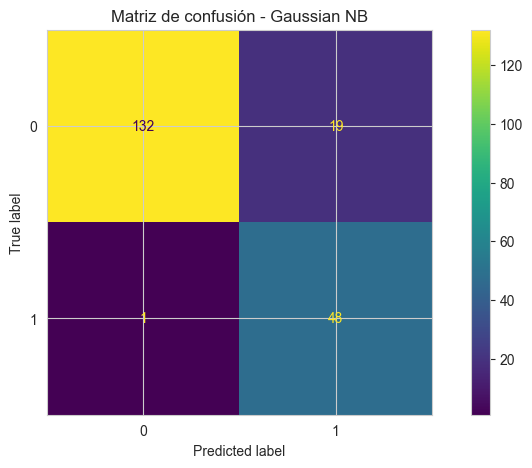

In [9]:
modelos_clasificacion = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=3000,
        class_weight="balanced"
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=6,
        class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=8,
        class_weight="balanced"
    ),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(
        random_state=42,
        class_weight="balanced",
        probability=True
    ),
    "Gaussian NB": GaussianNB()
}

resultados_clasificacion = []
pipelines_clasificacion = {}

for nombre, modelo in modelos_clasificacion.items():
    resultado, pipeline = evaluar_modelo_clasificacion(
        nombre,
        modelo,
        X_train_clf,
        X_test_clf,
        y_train_clf,
        y_test_clf
    )

    resultados_clasificacion.append(resultado)
    pipelines_clasificacion[nombre] = pipeline


# 10. Comparación de modelos de clasificación

Se consolidan las métricas principales en una tabla comparativa.


In [10]:
tabla_clasificacion = pd.DataFrame(resultados_clasificacion)

tabla_clasificacion.sort_values(by="f1_score", ascending=False)


,modelo,accuracy,balanced_accuracy,precision,recall,f1_score
2,Random Forest,0.980,0.979862,0.941176,0.979592,0.960000
1,Decision Tree,0.965,0.963036,0.903846,0.959184,0.930693
0,Logistic Regression,0.945,0.956683,0.827586,0.979592,0.897196
4,SVM,0.935,0.943168,0.810345,0.959184,0.878505
3,KNN,0.925,0.908974,0.826923,0.877551,0.851485
5,Gaussian NB,0.900,0.926882,0.716418,0.979592,0.827586


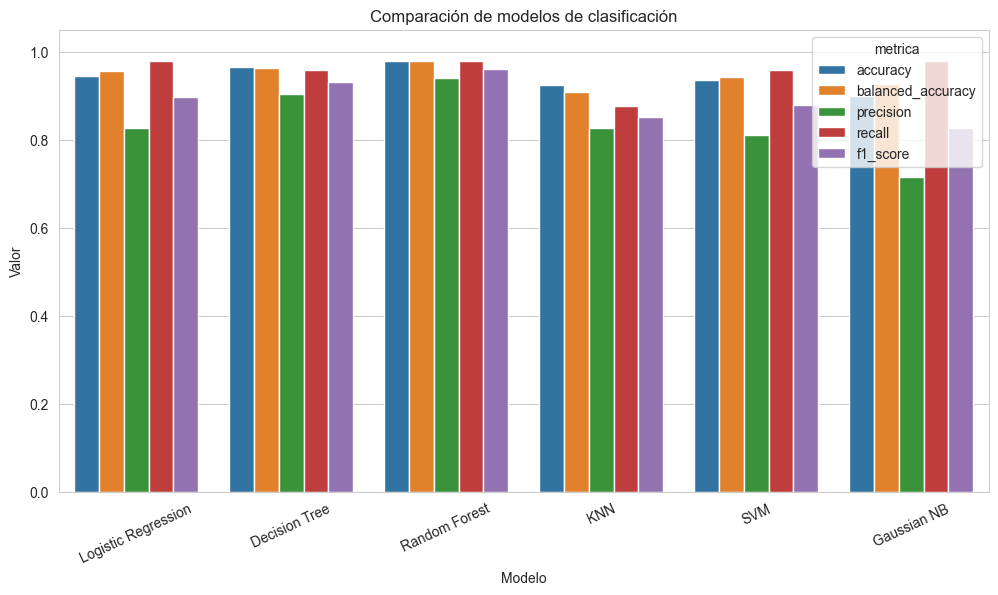

In [11]:
tabla_clf_melt = tabla_clasificacion.melt(
    id_vars="modelo",
    value_vars=["accuracy", "balanced_accuracy", "precision", "recall", "f1_score"],
    var_name="metrica",
    value_name="valor"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=tabla_clf_melt,
    x="modelo",
    y="valor",
    hue="metrica"
)

plt.title("Comparación de modelos de clasificación")
plt.xlabel("Modelo")
plt.ylabel("Valor")
plt.xticks(rotation=25)
plt.ylim(0, 1.05)

plt.show()


## Análisis de clasificación

La comparación permite observar qué modelos detectan mejor los envíos de alto riesgo operacional.

El modelo más fuerte esperado es Random Forest, ya que puede capturar relaciones no lineales entre variables como:

- uso de capacidad;
- distancia;
- sobrecarga;
- velocidad;
- tipo de vía;
- estado del vehículo.

En este problema no basta con mirar accuracy.  
También se debe revisar balanced accuracy, precision, recall y F1-score, porque el objetivo es detectar correctamente la clase de alto riesgo sin ignorar la clase normal.


# 11. Selección del mejor modelo de clasificación

Se selecciona el mejor modelo según F1-score, considerando también balanced accuracy y recall.


In [12]:
mejor_clf = tabla_clasificacion.sort_values(
    by="f1_score",
    ascending=False
).iloc[0]

mejor_modelo_clf_nombre = mejor_clf["modelo"]

print("Mejor modelo de clasificación:", mejor_modelo_clf_nombre)

display(mejor_clf)


Mejor modelo de clasificación: Random Forest



modelo               Random Forest
accuracy                      0.98
balanced_accuracy         0.979862
precision                 0.941176
recall                    0.979592
f1_score                      0.96
Name: 2, dtype: object

## Interpretación de la selección

El mejor modelo de clasificación será utilizado como referencia para la etapa de optimización posterior.

Si Random Forest aparece como mejor modelo, esto es coherente con la naturaleza del problema, ya que el riesgo operacional depende de combinaciones complejas de variables y no solo de una relación lineal simple.


# 12. Curvas ROC para modelos de clasificación

Se comparan las curvas ROC de los modelos que pueden producir probabilidades o scores de decisión.

Esto permite evaluar la capacidad de separar la clase de alto riesgo frente a la clase normal.


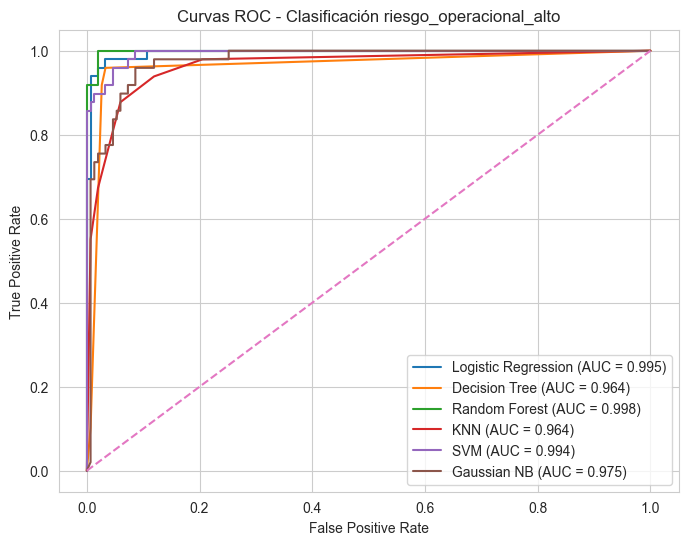

In [13]:
plt.figure(figsize=(8, 6))

for nombre, pipeline in pipelines_clasificacion.items():
    modelo = pipeline.named_steps["modelo"]

    try:
        if hasattr(modelo, "predict_proba"):
            y_score = pipeline.predict_proba(X_test_clf)[:, 1]
        elif hasattr(modelo, "decision_function"):
            y_score = pipeline.decision_function(X_test_clf)
        else:
            continue

        fpr, tpr, _ = roc_curve(y_test_clf, y_score)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{nombre} (AUC = {roc_auc:.3f})")

    except Exception as e:
        print(f"No se pudo calcular ROC para {nombre}: {e}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Curvas ROC - Clasificación riesgo_operacional_alto")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


## Análisis de curvas ROC

Las curvas ROC muestran la capacidad de cada modelo para separar correctamente los envíos de alto riesgo operacional respecto a los envíos normales.

Los resultados obtenidos evidencian un desempeño sobresaliente en todos los modelos evaluados, ya que todos alcanzan valores AUC superiores a `0.96`.

El modelo con mejor rendimiento fue **Random Forest**, alcanzando un AUC de `0.998`, lo que indica una capacidad casi perfecta para distinguir entre ambas clases.

Esto sugiere que el riesgo operacional no depende de una única variable, sino de combinaciones complejas entre factores como:

- uso de capacidad,
- sobrecarga,
- distancia recorrida,
- velocidad promedio,
- tipo de vía,
- estado del vehículo.

Además, el alto desempeño de **Logistic Regression** y **SVM** demuestra que el problema posee patrones consistentes y altamente separables.

En términos operacionales, esto confirma que el dataset contiene señales relevantes para identificar operaciones logísticas de alto riesgo antes de que ocurran problemas reales.

# 13. Importancia de variables del mejor clasificador

Si el mejor clasificador permite calcular importancia de variables, se revisan las variables más influyentes.

Esto ayuda a interpretar el modelo desde una perspectiva operacional.


,variable,importancia
8,num__uso_capacidad_kg,0.206568
10,num__uso_capacidad_kg_recalculado,0.179083
16,num__sobrecarga_kg,0.087587
0,num__distancia_km,0.074342
22,num__distancia_km_log,0.057402
15,num__vehiculo_exigido,0.053119
4,num__capacidad_kg,0.052313
26,num__riesgo_velocidad_log,0.042239
14,num__riesgo_velocidad,0.041162
21,num__peso_kg_log,0.022299


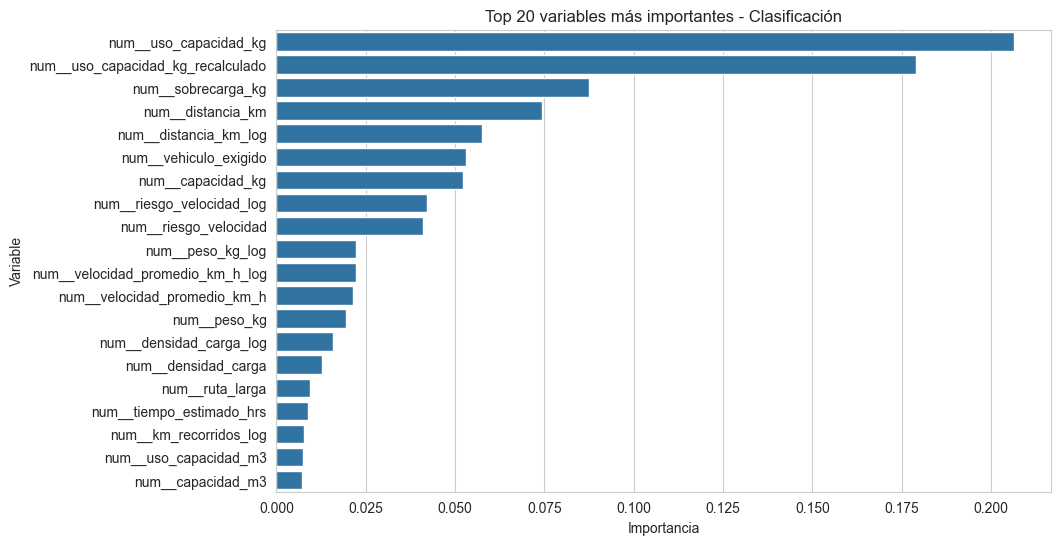

In [14]:
mejor_pipeline_clf = pipelines_clasificacion[mejor_modelo_clf_nombre]
modelo_final_clf = mejor_pipeline_clf.named_steps["modelo"]
preprocesador_final_clf = mejor_pipeline_clf.named_steps["preprocesamiento"]

if hasattr(modelo_final_clf, "feature_importances_"):
    nombres_features = preprocesador_final_clf.get_feature_names_out()

    importancias_clf = pd.DataFrame({
        "variable": nombres_features,
        "importancia": modelo_final_clf.feature_importances_
    }).sort_values(by="importancia", ascending=False)

    display(importancias_clf.head(20))

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=importancias_clf.head(20),
        x="importancia",
        y="variable"
    )

    plt.title("Top 20 variables más importantes - Clasificación")
    plt.xlabel("Importancia")
    plt.ylabel("Variable")

    plt.show()

else:
    print("El mejor modelo seleccionado no entrega feature_importances_.")


## Análisis de importancia de variables

La importancia de variables permite revisar si el modelo está aprendiendo patrones coherentes con la operación.

En un buen modelo de riesgo operacional, se espera que aparezcan variables relacionadas con:

- uso de capacidad;
- sobrecarga;
- distancia;
- velocidad;
- riesgo de velocidad;
- vehículo exigido.

Esto ayuda a validar que el modelo no solo tiene buen rendimiento, sino que además aprende relaciones interpretables para el negocio.


# 14. Modelado de regresión

## Target: `riesgo_operacional`

En esta sección se entrenan los modelos de regresión solicitados:

- Linear Regression;
- Decision Tree Regressor;
- Random Forest Regressor;
- KNN Regressor;
- SVR.

La finalidad es estimar el nivel numérico de riesgo operacional.


In [15]:
datos_reg = df[variables_modelo + [target_regresion]].dropna(subset=[target_regresion]).copy()

X_reg = datos_reg[variables_modelo].copy()
y_reg = datos_reg[target_regresion].copy()

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train_reg.shape)
print("X_test:", X_test_reg.shape)

print("\nResumen del target de regresión:")
display(y_reg.describe())


X_train: (776, 32)
X_test: (195, 32)

Resumen del target de regresión:



count      971.000000
mean      1832.021294
std       2479.975768
min          0.355957
25%        348.299907
50%        925.223706
75%       2279.954104
max      20000.000000
Name: riesgo_operacional, dtype: float64

## Análisis del target de regresión

El target `riesgo_operacional` es una variable continua.

A diferencia de la clasificación, aquí no se busca responder “alto riesgo sí/no”, sino estimar un puntaje numérico.

Esto permite ordenar envíos según criticidad y priorizar aquellos con mayor nivel de riesgo.


# 15. Función de evaluación para regresión

Se define una función común para entrenar y evaluar modelos de regresión.


In [16]:
def evaluar_modelo_regresion(nombre_modelo, modelo, X_train, X_test, y_train, y_test):
    pipeline = Pipeline([
        ("preprocesamiento", crear_preprocesador(X_train)),
        ("modelo", modelo)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    resultado = {
        "modelo": nombre_modelo,
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": rmse,
        "r2": r2_score(y_test, y_pred)
    }

    print(f"===== {nombre_modelo} =====")
    print(f"MAE  : {resultado['mae']:.4f}")
    print(f"RMSE : {resultado['rmse']:.4f}")
    print(f"R²   : {resultado['r2']:.4f}")

    comparacion = pd.DataFrame({
        "Real": y_test.values,
        "Predicción": y_pred
    }).head(10)

    display(comparacion)

    return resultado, pipeline, y_pred


# 16. Entrenamiento de modelos de regresión

Se entrenan los modelos base sin optimización exhaustiva.


In [17]:
modelos_regresion = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(
        random_state=42,
        max_depth=6
    ),
    "Random Forest Regressor": RandomForestRegressor(
        random_state=42,
        n_estimators=200,
        max_depth=8
    ),
    "KNN Regressor": KNeighborsRegressor(),
    "SVR": SVR()
}

resultados_regresion = []
pipelines_regresion = {}
predicciones_regresion = {}

for nombre, modelo in modelos_regresion.items():
    resultado, pipeline, y_pred = evaluar_modelo_regresion(
        nombre,
        modelo,
        X_train_reg,
        X_test_reg,
        y_train_reg,
        y_test_reg
    )

    resultados_regresion.append(resultado)
    pipelines_regresion[nombre] = pipeline
    predicciones_regresion[nombre] = y_pred


===== Linear Regression =====
MAE  : 703.5535
RMSE : 1092.9186
R²   : 0.6427


,Real,Predicción
0,8128.500000,6244.942097
1,6359.600000,5801.985902
2,372.049662,-29.177570
3,874.370650,1543.538080
4,1746.921410,1905.487353
5,2332.587290,2207.437895
6,49.100064,-871.813529
7,604.078135,1758.037658
8,128.747382,302.595985
9,317.646684,-227.021783


===== Decision Tree Regressor =====
MAE  : 203.7518
RMSE : 334.7475
R²   : 0.9665


,Real,Predicción
0,8128.500000,7917.024502
1,6359.600000,4288.234020
2,372.049662,575.674643
3,874.370650,1058.777290
4,1746.921410,1667.233045
5,2332.587290,2287.515613
6,49.100064,177.174972
7,604.078135,582.956946
8,128.747382,244.054363
9,317.646684,253.241204


===== Random Forest Regressor =====
MAE  : 59.0731
RMSE : 131.4848
R²   : 0.9948


,Real,Predicción
0,8128.500000,8070.800643
1,6359.600000,6861.645231
2,372.049662,391.073291
3,874.370650,890.581552
4,1746.921410,1772.632872
5,2332.587290,2281.709692
6,49.100064,74.246619
7,604.078135,676.225336
8,128.747382,131.091177
9,317.646684,325.597231


===== KNN Regressor =====
MAE  : 453.2184
RMSE : 662.6950
R²   : 0.8686


,Real,Predicción
0,8128.500000,7150.200000
1,6359.600000,6044.686168
2,372.049662,461.237374
3,874.370650,1338.309316
4,1746.921410,1979.767877
5,2332.587290,1648.177428
6,49.100064,71.179731
7,604.078135,1114.485226
8,128.747382,207.390268
9,317.646684,288.066913


===== SVR =====
MAE  : 1130.8534
RMSE : 1870.5993
R²   : -0.0466


,Real,Predicción
0,8128.500000,1032.189968
1,6359.600000,996.312938
2,372.049662,944.671467
3,874.370650,969.001644
4,1746.921410,990.863565
5,2332.587290,991.976268
6,49.100064,961.407987
7,604.078135,974.788961
8,128.747382,940.868882
9,317.646684,927.915429


# 17. Comparación de modelos de regresión

Se comparan los modelos utilizando:

- MAE: error absoluto promedio;
- RMSE: error que penaliza más los errores grandes;
- R²: proporción de variabilidad explicada por el modelo.


In [18]:
tabla_regresion = pd.DataFrame(resultados_regresion)

tabla_regresion.sort_values(by="rmse", ascending=True)


,modelo,mae,rmse,r2
2,Random Forest Regressor,59.073087,131.484784,0.994829
1,Decision Tree Regressor,203.751751,334.747512,0.966485
3,KNN Regressor,453.218417,662.694984,0.868650
0,Linear Regression,703.553530,1092.918625,0.642744
4,SVR,1130.853390,1870.599274,-0.046562


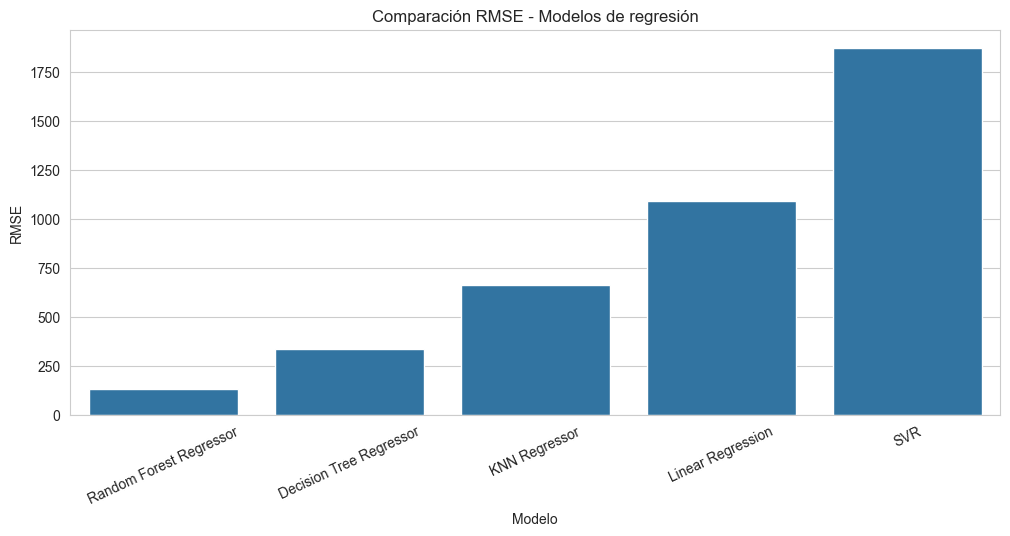

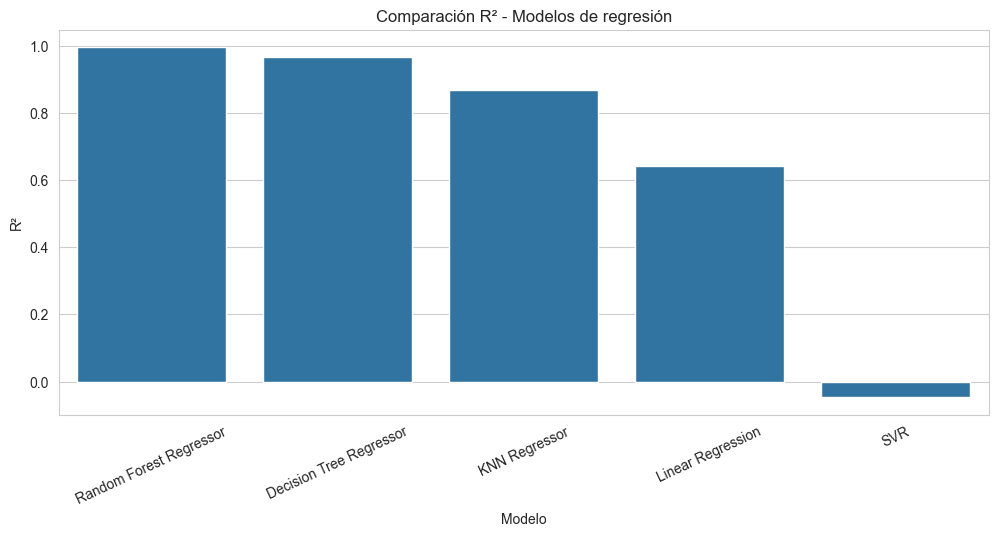

In [19]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=tabla_regresion.sort_values(by="rmse"),
    x="modelo",
    y="rmse"
)

plt.title("Comparación RMSE - Modelos de regresión")
plt.xlabel("Modelo")
plt.ylabel("RMSE")
plt.xticks(rotation=25)

plt.show()

plt.figure(figsize=(12, 5))

sns.barplot(
    data=tabla_regresion.sort_values(by="r2", ascending=False),
    x="modelo",
    y="r2"
)

plt.title("Comparación R² - Modelos de regresión")
plt.xlabel("Modelo")
plt.ylabel("R²")
plt.xticks(rotation=25)

plt.show()


## Análisis de regresión

El mejor modelo esperado es Random Forest Regressor.

Esto es coherente porque el riesgo operacional se relaciona con combinaciones no lineales entre distancia, capacidad, velocidad y carga.

Modelos más simples como Linear Regression pueden capturar relaciones generales, pero no necesariamente representan bien interacciones complejas.

SVR puede verse afectado por la escala y distribución del target si no se ajustan cuidadosamente sus hiperparámetros.


# 18. Selección del mejor modelo de regresión

Se selecciona el modelo con menor RMSE y mayor R².


In [20]:
mejor_reg = tabla_regresion.sort_values(
    by="rmse",
    ascending=True
).iloc[0]

mejor_modelo_reg_nombre = mejor_reg["modelo"]

print("Mejor modelo de regresión:", mejor_modelo_reg_nombre)

display(mejor_reg)


Mejor modelo de regresión: Random Forest Regressor



modelo    Random Forest Regressor
mae                     59.073087
rmse                   131.484784
r2                       0.994829
Name: 2, dtype: object

## Interpretación de la selección

El mejor modelo de regresión será la base para la etapa de optimización.

Un buen modelo de regresión en este contexto permite estimar la intensidad del riesgo operacional, lo cual puede usarse para ordenar envíos y priorizar revisiones.


# 19. Gráfico real vs predicho del mejor regresor

Se visualiza la relación entre los valores reales y predichos del mejor modelo de regresión.


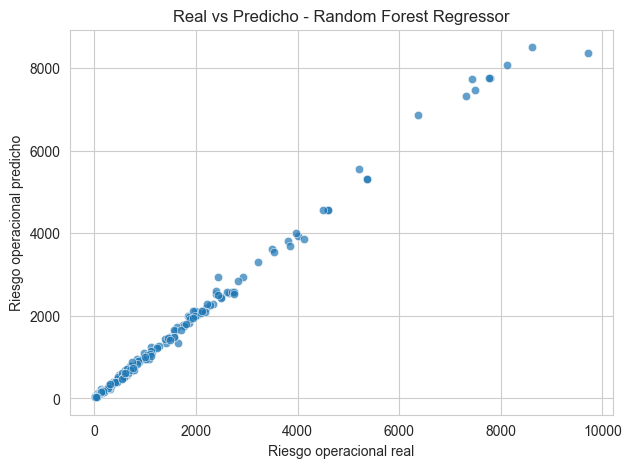

,Real,Predicción
0,8128.500000,8070.800643
1,6359.600000,6861.645231
2,372.049662,391.073291
3,874.370650,890.581552
4,1746.921410,1772.632872
5,2332.587290,2281.709692
6,49.100064,74.246619
7,604.078135,676.225336
8,128.747382,131.091177
9,317.646684,325.597231


In [21]:
y_pred_mejor_reg = predicciones_regresion[mejor_modelo_reg_nombre]

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=y_test_reg,
    y=y_pred_mejor_reg,
    alpha=0.7
)

plt.title(f"Real vs Predicho - {mejor_modelo_reg_nombre}")
plt.xlabel("Riesgo operacional real")
plt.ylabel("Riesgo operacional predicho")

plt.show()

comparacion_final_reg = pd.DataFrame({
    "Real": y_test_reg.values,
    "Predicción": y_pred_mejor_reg
}).head(15)

comparacion_final_reg


## Análisis del gráfico real vs predicho

El gráfico permite revisar visualmente la calidad del modelo.

Mientras más cerca estén los puntos de una diagonal imaginaria, mejor será la predicción.

En el caso del riesgo operacional, un buen ajuste indica que el modelo puede estimar de forma confiable el nivel de criticidad de los envíos.


# 20. Importancia de variables del mejor regresor

Si el mejor modelo permite calcular importancia de variables, se revisan las variables más influyentes.


,variable,importancia
8,num__uso_capacidad_kg,0.353146
0,num__distancia_km,0.175920
10,num__uso_capacidad_kg_recalculado,0.171120
22,num__distancia_km_log,0.170007
26,num__riesgo_velocidad_log,0.062990
14,num__riesgo_velocidad,0.055121
11,num__uso_capacidad_m3_recalculado,0.001290
3,num__volumen_m3,0.000953
9,num__uso_capacidad_m3,0.000846
23,num__volumen_m3_log,0.000692


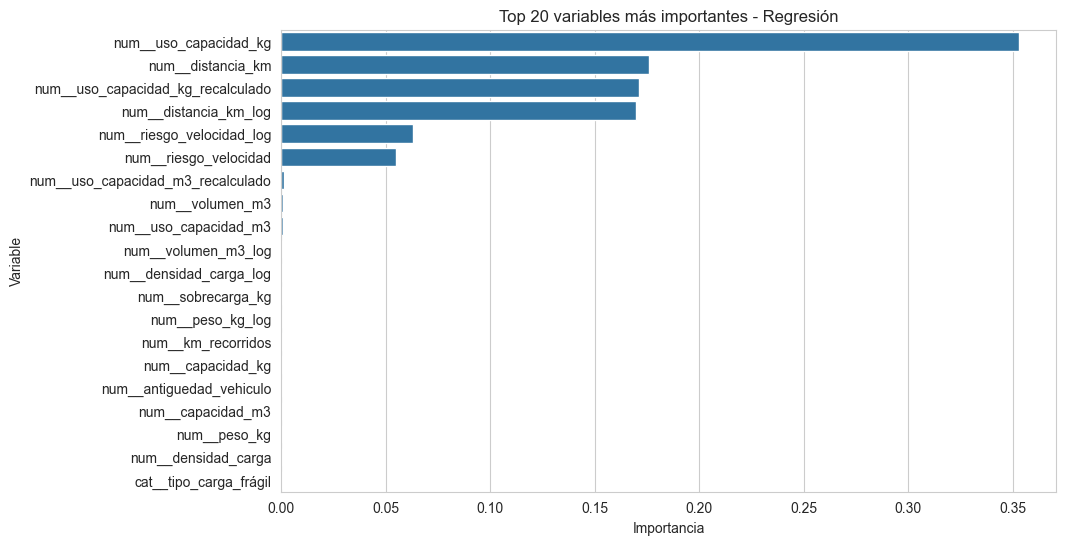

In [22]:
mejor_pipeline_reg = pipelines_regresion[mejor_modelo_reg_nombre]
modelo_final_reg = mejor_pipeline_reg.named_steps["modelo"]
preprocesador_final_reg = mejor_pipeline_reg.named_steps["preprocesamiento"]

if hasattr(modelo_final_reg, "feature_importances_"):
    nombres_features = preprocesador_final_reg.get_feature_names_out()

    importancias_reg = pd.DataFrame({
        "variable": nombres_features,
        "importancia": modelo_final_reg.feature_importances_
    }).sort_values(by="importancia", ascending=False)

    display(importancias_reg.head(20))

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=importancias_reg.head(20),
        x="importancia",
        y="variable"
    )

    plt.title("Top 20 variables más importantes - Regresión")
    plt.xlabel("Importancia")
    plt.ylabel("Variable")

    plt.show()

else:
    print("El mejor modelo seleccionado no entrega feature_importances_.")


## Análisis de importancia en regresión

La importancia de variables en regresión permite entender qué factores ayudan más a estimar el nivel de riesgo operacional.

Se espera que variables asociadas a distancia, capacidad, sobrecarga y velocidad tengan un rol relevante.

Esto conecta el modelo con la lógica operacional analizada en notebooks anteriores.


# 21. Comparación final entre clasificación y regresión

Se resumen los mejores modelos de cada enfoque supervisado.


In [23]:
resumen_final = pd.DataFrame([
    {
        "tipo_problema": "Clasificación",
        "target": "riesgo_operacional_alto",
        "mejor_modelo": mejor_modelo_clf_nombre,
        "metrica_principal": "F1-score",
        "valor_metrica": mejor_clf["f1_score"]
    },
    {
        "tipo_problema": "Regresión",
        "target": "riesgo_operacional",
        "mejor_modelo": mejor_modelo_reg_nombre,
        "metrica_principal": "RMSE",
        "valor_metrica": mejor_reg["rmse"]
    }
])

resumen_final


,tipo_problema,target,mejor_modelo,metrica_principal,valor_metrica
0,Clasificación,riesgo_operacional_alto,Random Forest,F1-score,0.960000
1,Regresión,riesgo_operacional,Random Forest Regressor,RMSE,131.484784


## Interpretación final

Los dos enfoques responden preguntas distintas:

## Clasificación

Permite generar una alerta:

> ¿Este envío es de alto riesgo operacional?

## Regresión

Permite estimar intensidad:

> ¿Qué nivel de riesgo operacional tiene este envío?

Ambos modelos se complementan y pueden utilizarse dentro de un sistema de apoyo a la decisión logística.


# 22. Conclusiones del notebook

En este notebook se implementaron modelos supervisados para clasificación y regresión.

## Clasificación

Se probaron:

- Logistic Regression;
- Decision Tree;
- Random Forest;
- KNN;
- SVM;
- GaussianNB.

El objetivo fue detectar envíos con alto riesgo operacional.

## Regresión

Se probaron:

- Linear Regression;
- Decision Tree Regressor;
- Random Forest Regressor;
- KNN Regressor;
- SVR.

El objetivo fue estimar el nivel continuo de riesgo operacional.

Los mejores modelos obtenidos en esta etapa serán utilizados como base para la optimización de hiperparámetros en el siguiente notebook.

Esta etapa permitió responder qué modelos funcionan mejor sin optimización y dejó preparada la comparación para mejorar configuraciones en `04_hyperparameter_optimization.ipynb`.
